# 00. Data Discovery — Riot TFT API

**Goal:** Systematically explore what data is available from Riot API 
for TFT Set 17 matches, before committing to a project direction.

**Questions to answer:**
1. What queue types are available?
2. How complete is data per participant?
3. What's the distribution of champions, items, traits?
4. Are augments truly absent, or hidden somewhere?
5. What's the relationship between data completeness and placement?

In [31]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
matches_dir = Path('../data/raw/challenger')
matches_files = list(matches_dir.glob('*.json'))
print(f'Found {len(matches_files)} matches files')

matches = []
for fp in matches_files:
    with open(fp) as f:
        matches.append(json.load(f))

print(f'Loaded {len(matches)} matches')

Found 195 matches files
Loaded 195 matches


In [33]:
queue_ids = [m['info']['queueId'] for m in matches]
queue_counter = Counter(queue_ids)
print('Queue ID distribution:')
for q, count in queue_counter.most_common():
    print(f'{q}: {count} matches')

Queue ID distribution:
1100: 178 matches
1160: 11 matches
1090: 5 matches
1220: 1 matches


In [34]:
augment_count_total = 0
augment_count_per_queue = Counter()

for m in matches:
    match_str = json.dumps(m).lower()
    aug_count = match_str.count('augment')
    augment_count_total += aug_count

    if aug_count > 0:
        q = m['info']['queueId']
        augment_count_per_queue[q] += aug_count

print(f'Total "augment" mentions across {len(matches)} matches: {augment_count_total}')
if augment_count_per_queue:
    print('Per queue type:')
    for q, c in augment_count_per_queue.items():
        print(f'  Queue {q}: {c}')
else:
    print('CONFIRMED: No augments in any of the 50 matches.')

Total "augment" mentions across 195 matches: 0
CONFIRMED: No augments in any of the 50 matches.


In [35]:
rows = []
for m in matches:
    match_id = m['metadata']['match_id']
    queue_id = m['info']['queue_id']
    for p in m['info']['participants']:
        rows.append({
            'match_id': match_id,
            'queue_id': queue_id,
            'placement': p['placement'],
            'level': p['level'],
            'last_round': p['last_round'],
            'num_units': len(p.get('units', [])),
            'num_traits_active': sum(1 for t in p.get('traits', []) if t['tier_current'] > 0),
            'total_items_count': sum(len(u.get('itemNames', [])) for u in p.get('units', [])),
            'units_with_items': sum(1 for u in p.get('units', []) if u.get('itemNames')),
        })

df = pd.DataFrame(rows)
print(f'Total participants: {len(df)}')
print(f'Across {df.match_id.nunique()} matches\n')
print(df.describe())

Total participants: 1553
Across 195 matches

          queue_id    placement        level   last_round    num_units  \
count  1553.000000  1553.000000  1553.000000  1553.000000  1553.000000   
mean   1103.219575     4.497746     8.377334    31.766259     8.428203   
std      14.339004     2.293008     0.889110     4.577240     1.444471   
min    1090.000000     1.000000     5.000000    13.000000     0.000000   
25%    1100.000000     2.000000     8.000000    28.000000     8.000000   
50%    1100.000000     4.000000     8.000000    31.000000     9.000000   
75%    1100.000000     6.000000     9.000000    35.000000     9.000000   
max    1220.000000     8.000000    10.000000    44.000000    18.000000   

       num_traits_active  total_items_count  units_with_items  
count        1553.000000        1553.000000       1553.000000  
mean            7.019961          11.806182          4.636188  
std             2.183346           3.300916          1.230373  
min             0.000000        

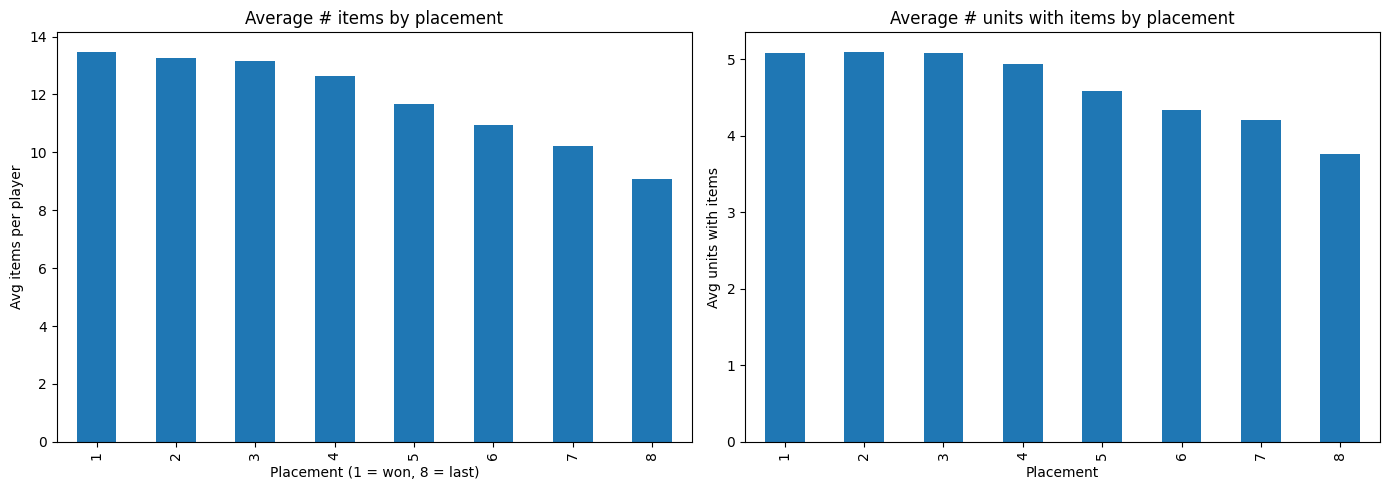

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('placement')['total_items_count'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Average # items by placement')
axes[0].set_xlabel('Placement (1 = won, 8 = last)')
axes[0].set_ylabel('Avg items per player')

df.groupby('placement')['units_with_items'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Average # units with items by placement')
axes[1].set_xlabel('Placement')
axes[1].set_ylabel('Avg units with items')

plt.tight_layout()
plt.show()

In [37]:
all_champions = []
for m in matches:
    for p in m['info']['participants']:
        for u in p.get('units', []):
            all_champions.append(u['character_id'])

champion_counter = Counter(all_champions)
print(f'Unique champions: {len(champion_counter)}')
print(f'\nTop 20 most popular champions:')
for champ, count in champion_counter.most_common(20):
    print(f'  {champ}: {count}')

Unique champions: 66

Top 20 most popular champions:
  TFT17_Mordekaiser: 559
  TFT17_Nunu: 510
  TFT17_IvernMinion: 484
  TFT17_Rhaast: 446
  TFT17_Rammus: 415
  TFT17_Illaoi: 399
  TFT17_Karma: 359
  TFT17_TahmKench: 349
  TFT17_Blitzcrank: 340
  TFT17_Jax: 339
  TFT17_Summon: 337
  TFT17_Maokai: 324
  TFT17_Akali: 321
  TFT17_Shen: 320
  TFT17_Lissandra: 293
  TFT17_Aatrox: 287
  TFT17_Xayah: 272
  TFT17_Galio: 268
  TFT17_Riven: 267
  TFT17_Ornn: 265


In [38]:
all_items = []
for m in matches:
    for p in m['info']['participants']:
        for u in p.get('units', []):
            all_items.extend(u.get('itemNames', []))

item_counter = Counter(all_items)
print(f'Total items observed: {len(all_items)}')
print(f'Unique items: {len(item_counter)}')
print(f'\nTop 20 most popular items:')
for item, count in item_counter.most_common(20):
    print(f'  {item}: {count}')

Total items observed: 18335
Unique items: 177

Top 20 most popular items:
  TFT_Item_GargoyleStoneplate: 972
  TFT_Item_GuinsoosRageblade: 903
  TFT_Item_JeweledGauntlet: 793
  TFT_Item_MadredsBloodrazor: 787
  TFT_Item_Redemption: 691
  TFT_Item_WarmogsArmor: 686
  TFT_Item_RedBuff: 681
  TFT_Item_InfinityEdge: 609
  TFT_Item_SpearOfShojin: 563
  TFT_Item_FrozenHeart: 531
  TFT_Item_Leviathan: 449
  TFT_Item_ThiefsGloves: 442
  TFT_Item_PowerGauntlet: 416
  TFT_Item_StatikkShiv: 412
  TFT_Item_DragonsClaw: 388
  TFT_Item_RabadonsDeathcap: 367
  TFT_Item_NightHarvester: 361
  TFT_Item_Bloodthirster: 359
  TFT_Item_Deathblade: 353
  TFT_Item_Quicksilver: 349


In [39]:
all_traits_active = []
for m in matches:
    for p in m['info']['participants']:
        for t in p.get('traits', []):
            if t['tier_current'] > 0:
                all_traits_active.append(t['name'])

trait_counter = Counter(all_traits_active)
print(f'Unique traits with activated synergies: {len(trait_counter)}')
print(f'\nTop 20 traits:')
for trait, count in trait_counter.most_common(20):
    print(f'  {trait}: {count}')

Unique traits with activated synergies: 41

Top 20 traits:
  TFT17_ShieldTank: 770
  TFT17_ResistTank: 722
  TFT17_SpaceGroove: 703
  TFT17_DarkStar: 650
  TFT17_FlexTrait: 555
  TFT17_HPTank: 545
  TFT17_DRX: 447
  TFT17_RhaastUniqueTrait: 442
  TFT17_ManaTrait: 414
  TFT17_MeleeTrait: 400
  TFT17_TahmKenchUniqueTrait: 347
  TFT17_BlitzcrankUniqueTrait: 334
  TFT17_SummonTrait: 333
  TFT17_AssassinTrait: 317
  TFT17_ShenUniqueTrait: 314
  TFT17_Astronaut: 301
  TFT17_RangedTrait: 290
  TFT17_APTrait: 282
  TFT17_JhinUniqueTrait: 257
  TFT17_PsyOps: 252


In [40]:
print('=' * 60)
print('DATA DISCOVERY SUMMARY')
print('=' * 60)
print(f'Total matches: {len(matches)}')
print(f'Total participant records: {len(df)}')
print(f'Unique champions: {len(champion_counter)}')
print(f'Unique items: {len(item_counter)}')
print(f'Unique traits: {len(trait_counter)}')
print(f'\nAvg items per player: {df.total_items_count.mean():.2f}')
print(f'Avg items per top-2 player: {df[df.placement <= 2].total_items_count.mean():.2f}')
print(f'\nAugments: {"PRESENT" if augment_count_total else "ABSENT"}')

DATA DISCOVERY SUMMARY
Total matches: 195
Total participant records: 1553
Unique champions: 66
Unique items: 177
Unique traits: 41

Avg items per player: 11.81
Avg items per top-2 player: 13.37

Augments: ABSENT
